In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import tensorflow as tf
import os
import random

In [2]:

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomTranslation(height_factor=0.2, width_factor=0.2),
    tf.keras.layers.RandomContrast(0.2),
])
def data_aug(img):
    img = np.array(img)/255
    augmented = data_augmentation([img])
    return np.array(augmented[0])

In [3]:
root = './train'
buckets = {}
images = []
labels = []
augmented = []
factor = {'akiec': 2, 'bcc': 1, 'df': 6, 'vasc': 5}

h, w = 224, 224
for img_name in os.listdir(root):
    class_img = img_name.split('_')[0]
    if class_img == 'nv': continue
    img = cv.imread(os.path.join(root,img_name))
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    img = cv.resize(img, (h, w))
    # img = transform(img)
    if class_img in buckets: buckets[class_img]+=1
    else: buckets[class_img] = 0
    transformed_image = np.array(img)/255
    images.append(transformed_image)
    labels.append(class_img)
    if class_img in factor:
        for _ in range(factor[class_img]):
            buckets[class_img] += 1
            augmented_img = data_aug(img)
            images.append(augmented_img)
            labels.append(class_img)
print(len(images))
print(len(labels))

5878
5878


In [4]:
print(buckets)

{'bkl': 1098, 'mel': 1112, 'df': 804, 'bcc': 1027, 'akiec': 980, 'vasc': 851}


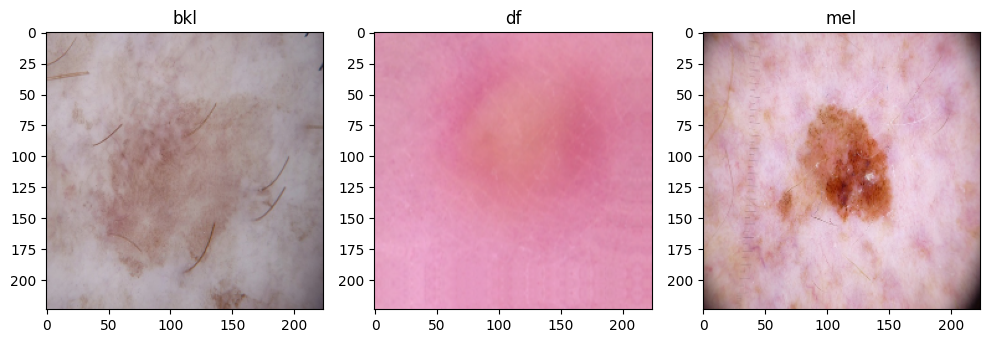

In [5]:
i = random.randint(0,len(images))
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.imshow(images[i])
plt.title(labels[i])
i = random.randint(0,len(images))
plt.subplot(1,3,2)
plt.imshow(images[i])
plt.title(labels[i])
plt.tight_layout()
i = random.randint(0,len(images))
plt.subplot(1,3,3)
plt.imshow(images[i])
plt.title(labels[i])
plt.tight_layout()
plt.show()

In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
labels = le.fit_transform(labels)
images = np.array(images)
labels = np.array(labels)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, shuffle=True, random_state=42)
X_train = X_train
X_test = X_test

Text(0.5, 1.0, '2, test')

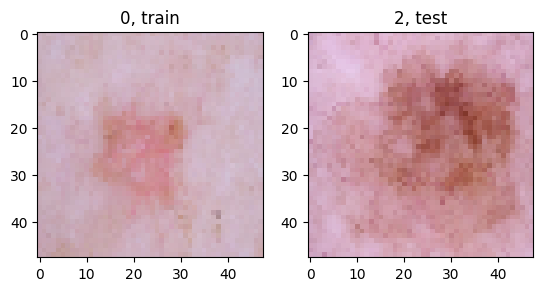

In [ ]:
plt.subplot(1,2,1)
i = random.randint(0,len(X_train))
plt.imshow(X_train[i])
plt.title(f'{y_train[i]}, train')
i = random.randint(0,len(X_test))
plt.subplot(1,2,2)
plt.imshow(X_test[i])
plt.title(f'{y_test[i]}, test')

In [ ]:
# bucks = {}
# train_dir = './train_dir'
# test_dir = './test_dir'
# for i in range(len(y_train)):
#     dx = le.inverse_transform([y_train[i]])[0]
#     if dx in bucks: bucks[dx]+=1
#     else: bucks[dx] = 0
#     img = cv.cvtColor(X_train[i], cv.COLOR_RGB2BGR)
#     cv.imwrite(os.path.join(train_dir, f'{dx}_{bucks[dx]}.jpg'), img)

# print('train: ',bucks)
# bucks = {}
# for i in range(len(y_test)):
#     dx = le.inverse_transform([y_test[i]])[0]
#     if dx in bucks: bucks[dx]+=1
#     else: bucks[dx] = 0
#     img = cv.cvtColor(X_test[i], cv.COLOR_RGB2BGR)
#     cv.imwrite(os.path.join(test_dir, f'{dx}_{bucks[dx]}.jpg'), img)
# print('test: ',bucks)

In [ ]:
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
# from tensorflow.keras.utils import to_categorical

# y_train = to_categorical(y_train)
# y_test = to_categorical(y_test)

# model = Sequential([
#     Conv2D(32, (3, 3), activation='relu', input_shape=(h, w, 3)),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),
    
#     Conv2D(64, (3, 3), activation='relu'),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Conv2D(128, (3, 3), activation='relu'),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Conv2D(128, (3, 3), activation='relu'),
#     BatchNormalization(),
#     MaxPooling2D((2, 2)),

#     Flatten(),
#     Dense(512, activation='relu'),
#     Dense(6, activation='softmax')
# ])

# model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.regularizers import l2

def residual_block(x, filters, kernel_size=3, stride=1, conv_shortcut=False):
    """
    Residual block with optional shortcut connection.
    """
    shortcut = x
    if conv_shortcut:
        shortcut = layers.Conv2D(filters, kernel_size=1, strides=stride, padding='same', kernel_regularizer=l2(0.001))(x)
        shortcut = layers.BatchNormalization()(shortcut)
    
    x = layers.Conv2D(filters, kernel_size, strides=stride, padding='same', kernel_regularizer=l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    x = layers.Conv2D(filters, kernel_size, strides=1, padding='same', kernel_regularizer=l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    
    # Ensure shortcut and x have the same shape
    if shortcut.shape[1:] != x.shape[1:]:
        shortcut = layers.Conv2D(filters, kernel_size=1, strides=stride, padding='same', kernel_regularizer=l2(0.001))(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    
    x = layers.add([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def create_advanced_cnn(input_shape=(h, w, 3), num_classes=6):
    inputs = layers.Input(shape=input_shape)
    
    x = layers.Conv2D(64, (7, 7), strides=(2, 2), padding='same', kernel_regularizer=l2(0.001))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    x = residual_block(x, 64, conv_shortcut=True)
    x = residual_block(x, 64)
    x = residual_block(x, 128, stride=2, conv_shortcut=True)
    x = residual_block(x, 128)
    x = residual_block(x, 256, stride=2, conv_shortcut=True)
    x = residual_block(x, 256)
    
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = models.Model(inputs, outputs)
    
    return model

model = create_advanced_cnn()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 48, 48, 3)]          0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 24, 24, 64)           9472      ['input_1[0][0]']             
                                                                                                  
 batch_normalization (Batch  (None, 24, 24, 64)           256       ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 activation (Activation)     (None, 24, 24, 64)           0         ['batch_normalization[0][0

In [ ]:
callbacks = [ tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5), 
            tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3)]

history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test), callbacks=callbacks)

Epoch 1/50
147/147 [==============================] - 26s 167ms/step - loss: 3.5665 - accuracy: 0.4234 - val_loss: 4.2369 - val_accuracy: 0.1709 - lr: 0.0010
Epoch 2/50
147/147 [==============================] - 25s 173ms/step - loss: 2.6638 - accuracy: 0.5136 - val_loss: 3.2560 - val_accuracy: 0.2347 - lr: 0.0010
Epoch 3/50
147/147 [==============================] - 24s 164ms/step - loss: 2.1516 - accuracy: 0.5328 - val_loss: 3.3088 - val_accuracy: 0.2577 - lr: 0.0010
Epoch 4/50
147/147 [==============================] - 25s 168ms/step - loss: 1.8432 - accuracy: 0.5621 - val_loss: 2.7184 - val_accuracy: 0.2075 - lr: 0.0010
Epoch 5/50
147/147 [==============================] - 28s 189ms/step - loss: 1.6644 - accuracy: 0.5647 - val_loss: 3.6299 - val_accuracy: 0.2219 - lr: 0.0010
Epoch 6/50
147/147 [==============================] - 25s 173ms/step - loss: 1.5114 - accuracy: 0.5897 - val_loss: 2.0469 - val_accuracy: 0.3988 - lr: 0.0010
Epoch 7/50
147/147 [==============================] 

In [ ]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print('Test Accuracy: %.3f' % acc)

Test Accuracy: 0.700


37/37 [==============================] - 2s 46ms/step


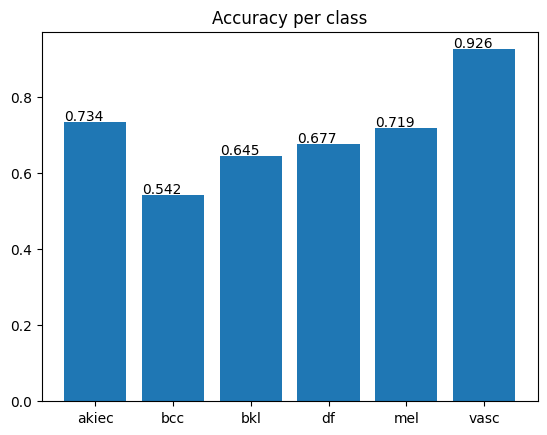

In [ ]:
y_pred = model.predict(X_test)
y_pred_label = np.argmax(y_pred, axis=1)
y_test_label = np.argmax(y_test, axis=1)

from sklearn.metrics import accuracy_score
acc_per_class = []
for i in range(6):
    acc_per_class.append(accuracy_score(y_test_label[y_test_label==i], y_pred_label[y_test_label==i]))

bars  = plt.bar(le.classes_, acc_per_class)
plt.title('Accuracy per class')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x(), yval + .005, round(yval,3))
plt.show()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
/var/folders/kq/c30lmhwd0pndxxdwyxyjvtqh0000gn/T/ipykernel_5039/1407297896.py:5: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(1, 2, 1)


Text(0, 0.5, 'Loss')

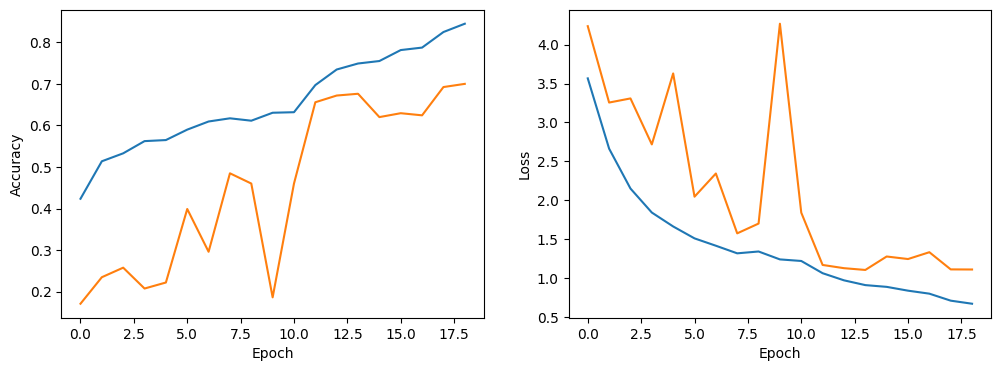

In [ ]:
model.save('model_complex.keras')
model.save('model_complex_legacy.h5')
plt.figure(figsize=(12,4))
plt.grid()
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')